# CNN Interpretability with CAM

This report explores how interpretable convolutional neural networks are by using Class Activation Mapping (CAM). Its aim is to examine and develop an understanding of which regions of an image influence a model’s predictions.

In [1]:
from cam import predict, show_cam, compare_layers

images = {
    'tabby_pos': 'tabby.jpeg',
    'tabby_neg': 'siamese_cat.jpeg',
    'golden_pos': 'golden_retriever.jpeg',
    'golden_neg': 'tibetan_mastiff.jpeg',
    'sports_car_pos': 'sport_car.jpeg',
    'sports_car_neg': 'ice_cream.jpeg',
    'unknown': 'et.jpeg'
}

## Method
A pretrained convolutional neural network, ResNet18, is used to perform image classification on ImageNet classes. To interpret the model’s predictions.

For each selected class, one positive example (an image containing the target object) and one negative example (an image not containing the target object) are analyzed. The model’s predictions, including logits and probabilities, are examined alongside the corresponding attribution maps.

In addition, a comparison between different network layers is performed to study how feature representations evolve throughout the model. Finally, an example of an image containing a class not present in ImageNet is included to evaluate how the model behaves when encountering unfamiliar objects.

## Class 1: tabby — positive

Top predictions:
1. tabby | id=281 | prob=0.7824 | logit=16.553
2. Egyptian cat | id=285 | prob=0.1467 | logit=14.879
3. tiger cat | id=282 | prob=0.0690 | logit=14.125
4. doormat | id=539 | prob=0.0003 | logit=8.667
5. lynx | id=287 | prob=0.0002 | logit=8.173


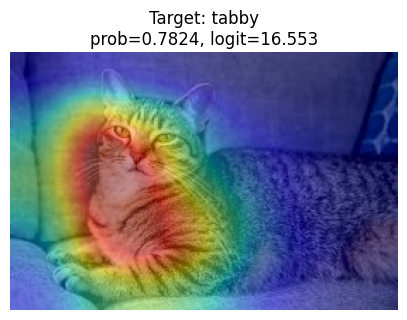

In [2]:
predict(images['tabby_pos'])
show_cam(images['tabby_pos'], target_class='tabby')

In the positive example, the model correctly predicts the class tabby with a high probability (0.7824) and a high logit value (16.553). This indicates strong confidence in the prediction.

The attribution map shows that the model focuses mainly on the face and upper body of the cat, especially around the eyes, nose, and fur patterns. These are highly relevant features for identifying a tabby cat, as they contain important visual characteristics such as stripes and facial structure.

Additionally, the logits for similar classes like Egyptian cat and tiger cat are also relatively high. This suggests that the model has learned general cat-related features, and while it correctly identifies the tabby, it still considers other similar cat breeds as possible alternatives.

## Class 1: tabby — negative

Top predictions:
1. Siamese cat | id=284 | prob=0.9837 | logit=17.156
2. Chihuahua | id=151 | prob=0.0116 | logit=12.713
3. Egyptian cat | id=285 | prob=0.0030 | logit=11.360
4. toy terrier | id=158 | prob=0.0007 | logit=9.957
5. wallaby | id=104 | prob=0.0001 | logit=7.565


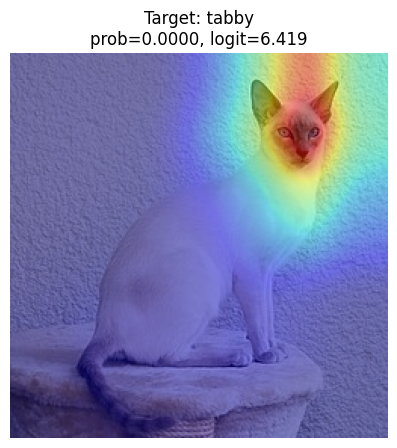

In [3]:
predict(images['tabby_neg'])
show_cam(images['tabby_neg'], target_class='tabby')

In the negative example, the image contains a Siamese cat, not a tabby. The model correctly predicts Siamese cat with very high confidence (0.9837), while the target class tabby has a very low probability and logit.

However, when generating the attribution map for the class tabby, the model still highlights the head and face region of the cat. This indicates that the model is detecting generic cat features, such as the shape of the head, ears, and eyes, even though the specific class (tabby) is not present.

Compared to the positive example, the activation is:

less specific to tabby features (e.g., no clear focus on striped fur)
more general and based on overall “cat-like” characteristics

Even though the model does not classify the image as a tabby, the CAM shows that it still activates on general cat features. This demonstrates that the network has learned shared visual patterns across similar classes.

## Class 2: golden retriever - positive

Top predictions:
1. golden retriever | id=207 | prob=0.9120 | logit=13.674
2. Labrador retriever | id=208 | prob=0.0172 | logit=9.701
3. Irish setter | id=213 | prob=0.0135 | logit=9.458
4. flat-coated retriever | id=205 | prob=0.0109 | logit=9.245
5. vizsla | id=211 | prob=0.0091 | logit=9.067


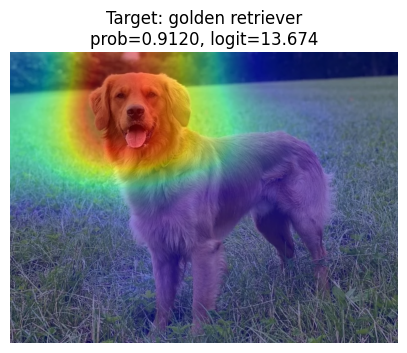

In [4]:
predict(images['golden_pos'])
show_cam(images['golden_pos'], target_class='golden retriever')

In the positive example, the model correctly predicts the class golden retriever with a high probability logit value, indicating strong confidence.

The attribution map shows that the model focuses primarily on the dog’s head and upper body, especially around the face and fur. These regions are highly relevant for identifying a golden retriever, as they contain characteristic features such as the shape of the head, the color and texture of the fur and the facial structure.

The logits also show relatively high values for similar dog breeds such as Labrador retriever and Irish setter. This suggests that the model has learned shared features among similar dog breeds, and distinguishes them based on finer details.

## Class 2: golden retriever - negative

Top predictions:
1. Tibetan mastiff | id=244 | prob=0.8647 | logit=16.106
2. chow | id=260 | prob=0.0957 | logit=13.905
3. Tibetan terrier | id=200 | prob=0.0176 | logit=12.209
4. Leonberg | id=255 | prob=0.0123 | logit=11.856
5. Newfoundland | id=256 | prob=0.0028 | logit=10.365


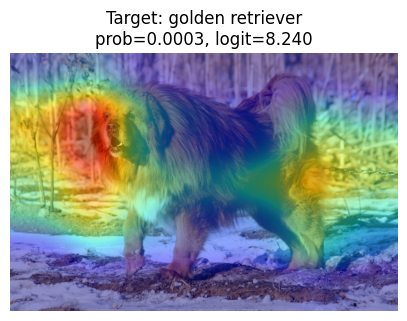

In [5]:
predict(images['golden_neg'])
show_cam(images['golden_neg'], target_class='golden retriever')

In the negative example, the image contains a Tibetan mastiff, and the model correctly predicts this class. The target class golden retriever has a very low probability, showing that the model does not consider this image to belong to that class.

However, when generating the attribution map for golden retriever, the model still highlights certain regions of the image. The strongest activation appears around the head and upper body of the dog, which indicates that the model is detecting general “dog-like” features.

Additionally, there is noticeable activation in the background area to the left of the dog’s head. This may be due to similarities in color and texture between the background and the typical fur of a golden retriever.

This suggests that the model is not only relying on object shape, but also on low-level features such as color and texture, which can sometimes lead to incorrect or misleading activations.

## Class 3: sports car

Top predictions:
1. racer | id=751 | prob=0.5082 | logit=14.863
2. sports car | id=817 | prob=0.4656 | logit=14.775
3. warplane | id=895 | prob=0.0099 | logit=10.921
4. car wheel | id=479 | prob=0.0084 | logit=10.761
5. cab | id=468 | prob=0.0012 | logit=8.850


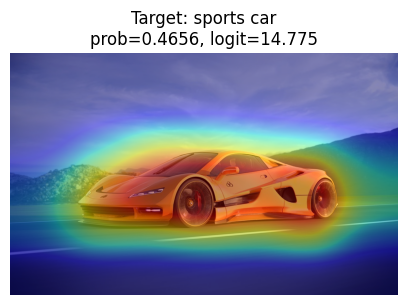

In [6]:
predict(images['sports_car_pos'])
show_cam(images['sports_car_pos'], target_class='sports car')

In the positive example, the model predicts the class sports car with a relatively high probability (0.4656), although the top prediction is racer (0.5082). This indicates that the model is somewhat uncertain between closely related classes, which is also supported by the very similar logit values.

The attribution map shows that the model focuses on the main body of the car, especially the wheels.

Top predictions:
1. ostrich | id=9 | prob=0.1579 | logit=8.447
2. ice cream | id=928 | prob=0.1380 | logit=8.312
3. mushroom | id=947 | prob=0.1200 | logit=8.172
4. stinkhorn | id=994 | prob=0.0633 | logit=7.533
5. knot | id=616 | prob=0.0504 | logit=7.304


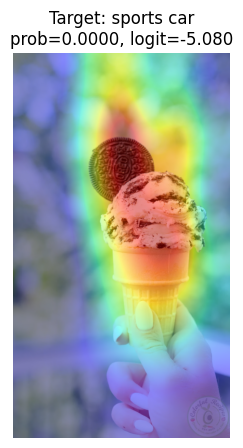

In [7]:
predict(images['sports_car_neg'])
show_cam(images['sports_car_neg'], target_class='sports car')

In the negative example, the image contains an ice cream, and the model correctly does not classify it as a sports car.

However, an interesting observation is that the model is also not very confident about the correct class (ice cream). The predicted probabilities are relatively low and spread across multiple unrelated classes such as ostrich, ice cream, and mushroom. This suggests that the model is uncertain and does not strongly recognize the object.

This uncertainty is likely due to the image not matching the model’s learned patterns, which makes it harder for the model to confidently associate it with the ice cream class from its training data.

Despite this, when generating the attribution map for sports car, the model highlights the ice cream cone and its rounded top, as well as parts of the hand. This indicates that the network is attempting to match basic shapes and patterns.

## Compare layers

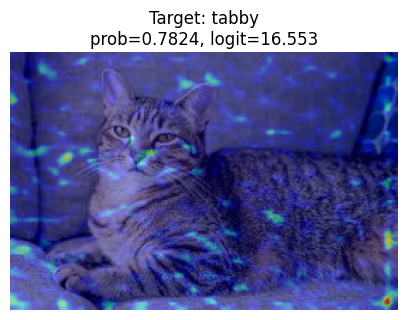

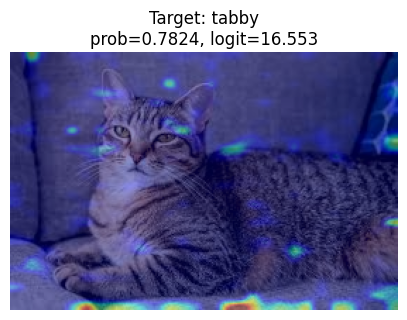

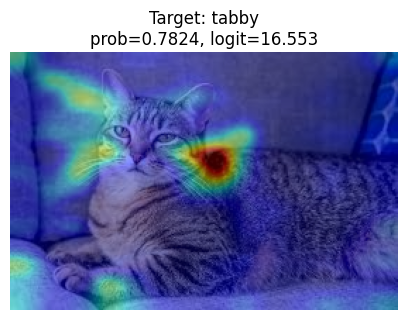

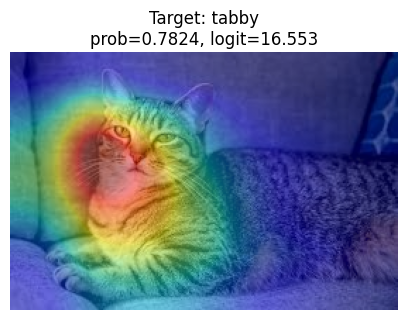

In [8]:
compare_layers(images['tabby_pos'], target_class='tabby')

In the early layer, the activation map is very scattered. It highlights many small points across the whole image, including both the cat and the background.

This suggests that early CNN layers mainly detect simple visual features such as edges, textures, color changes, and small patterns. At this stage, the model does not yet clearly understand where the cat is.

In the middle layers, the activation becomes more structured. The model starts focusing more on important regions of the image, especially around the cat’s face, ears, and some parts of the body.

However, there is still some activation in the background. This suggests that the middle layer has learned more complex patterns than the early layer, but it is not fully focused on the target object yet.

In the late layer, the activation is much more concentrated around the cat’s face and upper body. This is the most meaningful CAM result because it focuses on the parts that are most relevant for identifying a tabby cat, such as the face, eyes, and fur pattern.

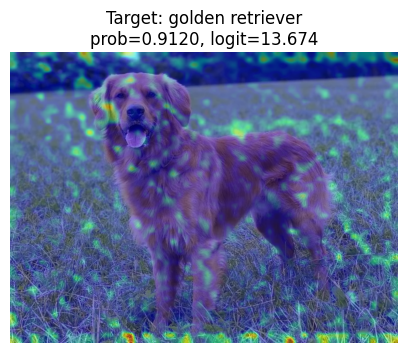

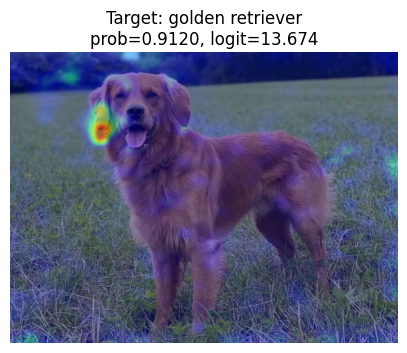

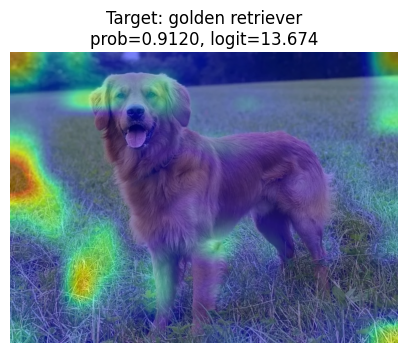

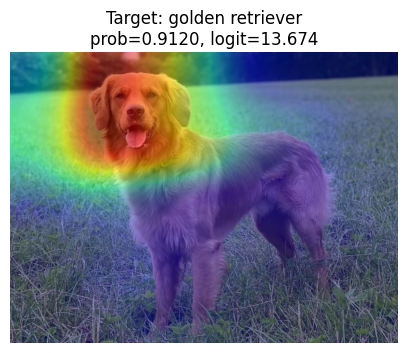

In [9]:
compare_layers(images['golden_pos'], target_class='golden retriever')

The same pattern observed in the tabby example is also present here. In the early layer, the activation is scattered across the image, showing that the model is detecting low-level features such as textures and edges without focusing on the object.

In the middle layers, the activation becomes more structured and starts to concentrate around the dog, especially the head, although some background regions are still highlighted.

In the late layer, the activation is clearly focused on the most important parts of the dog, particularly the face and upper body. This indicates that the model has learned to identify class-specific features relevant for recognizing a golden retriever.

## Class not present in ImageNet

Top predictions:
1. chimpanzee | id=367 | prob=0.7915 | logit=13.702
2. hippopotamus | id=344 | prob=0.1318 | logit=11.909
3. water buffalo | id=346 | prob=0.0126 | logit=9.564
4. African elephant | id=386 | prob=0.0071 | logit=8.989
5. bighorn | id=349 | prob=0.0057 | logit=8.760


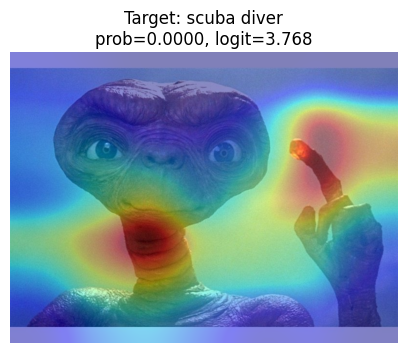

In [10]:
predict(images['unknown'])
show_cam(images['unknown'], target_class='scuba diver')

In this example, the image contains a character (E.T.) that is not part of the ImageNet dataset. As expected, the model is unable to correctly classify the object and instead predicts unrelated classes such as chimpanzee and hippopotamus.

This shows that the model is trying to match the image to the closest known categories based on learned features. Since E.T. has human-like and animal-like characteristics, the model associates it with animals it has seen during training.